This model loader can load pth models and use the model to predict results.

Compare the results with original image and ground truth mask.

The dataset path is assumed to exist in the same directory as the notebook.

In [97]:
# Gavin
# To use this script, you need to have pytorch installed.
# Type python pth_loader_simple.py in the terminal to run the script.

import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os

In [98]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels, do_batch_norm=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(out_channels) if do_batch_norm else nn.Identity()
        self.batch_norm2 = nn.BatchNorm2d(out_channels) if do_batch_norm else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.batch_norm1(self.conv1(x)))
        x = self.relu(self.batch_norm2(self.conv2(x)))
        return x

In [99]:
class UNet(nn.Module):
    """UNet architecture for image segmentation"""
    def __init__(self, in_channels=1, num_filters=16, dropout=0.1, do_batch_norm=True):
        super().__init__()
        
        # Encoder
        self.conv1 = Conv2dBlock(in_channels, num_filters, do_batch_norm=do_batch_norm)
        self.conv2 = Conv2dBlock(num_filters, num_filters*2, do_batch_norm=do_batch_norm)
        self.conv3 = Conv2dBlock(num_filters*2, num_filters*4, do_batch_norm=do_batch_norm)
        self.conv4 = Conv2dBlock(num_filters*4, num_filters*8, do_batch_norm=do_batch_norm)
        
        # Bridge
        self.bridge = Conv2dBlock(num_filters*8, num_filters*16, do_batch_norm=do_batch_norm)
        
        # Decoder
        self.up_conv4 = nn.ConvTranspose2d(num_filters*16, num_filters*8, kernel_size=2, stride=2)
        self.conv6 = Conv2dBlock(num_filters*16, num_filters*8, do_batch_norm=do_batch_norm)
        
        self.up_conv3 = nn.ConvTranspose2d(num_filters*8, num_filters*4, kernel_size=2, stride=2)
        self.conv7 = Conv2dBlock(num_filters*8, num_filters*4, do_batch_norm=do_batch_norm)
        
        self.up_conv2 = nn.ConvTranspose2d(num_filters*4, num_filters*2, kernel_size=2, stride=2)
        self.conv8 = Conv2dBlock(num_filters*4, num_filters*2, do_batch_norm=do_batch_norm)
        
        self.up_conv1 = nn.ConvTranspose2d(num_filters*2, num_filters, kernel_size=2, stride=2)
        self.conv9 = Conv2dBlock(num_filters*2, num_filters, do_batch_norm=do_batch_norm)
        
        self.output = nn.Conv2d(num_filters, 1, kernel_size=1)
        
        self.maxpool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder path
        c1 = self.conv1(x)
        p1 = self.dropout(self.maxpool(c1))
        
        c2 = self.conv2(p1)
        p2 = self.dropout(self.maxpool(c2))
        
        c3 = self.conv3(p2)
        p3 = self.dropout(self.maxpool(c3))
        
        c4 = self.conv4(p3)
        p4 = self.dropout(self.maxpool(c4))
        
        # Bridge
        bridge = self.bridge(p4)
        
        # Decoder path
        up4 = self.up_conv4(bridge)
        merge4 = torch.cat([up4, c4], dim=1)
        c6 = self.conv6(self.dropout(merge4))
        
        up3 = self.up_conv3(c6)
        merge3 = torch.cat([up3, c3], dim=1)
        c7 = self.conv7(self.dropout(merge3))
        
        up2 = self.up_conv2(c7)
        merge2 = torch.cat([up2, c2], dim=1)
        c8 = self.conv8(self.dropout(merge2))
        
        up1 = self.up_conv1(c8)
        merge1 = torch.cat([up1, c1], dim=1)
        c9 = self.conv9(self.dropout(merge1))
        
        output = self.sigmoid(self.output(c9))
        return output

In [100]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [101]:
def load_model(model_path):
    """Load model"""
    model = UNet(in_channels=1, num_filters=16, dropout=0.1, do_batch_norm=True)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

def preprocess_image(image_path, mask_path):
    """Preprocessing of the input image and mask""" 
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
    
    image = Image.open(image_path)
    original_image = transforms.Resize((256, 256))(image)
    image = transform(image)
    
    mask = Image.open(mask_path)
    original_mask = transforms.Resize((256, 256))(mask)
    
    return image.unsqueeze(0), original_image, original_mask

In [102]:
def display_results(original_image, mask_image, benign_pred, malignant_pred, title):
    """Display orignial image, ground truth mask and predicted masks"""
    plt.figure(figsize=(20, 5))
    
    # Original image
    plt.subplot(141)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Ground truth mask
    plt.subplot(142)
    plt.imshow(mask_image, cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')
    
    # Benign prediction
    plt.subplot(143)
    plt.imshow(benign_pred[0, 0], cmap='gray')
    plt.title('Benign Prediction')
    plt.axis('off')
    
    # Malignant prediction
    plt.subplot(144)
    plt.imshow(malignant_pred[0, 0], cmap='gray')
    plt.title('Malignant Prediction')
    plt.axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [103]:
def run_inference():
    # Load models
    print("Loading models...")
    benign_model = load_model('best_model_benign.pth')
    malignant_model = load_model('best_model_malignant.pth')
    
    # Set paths to image and mask
    # image_path = "Dataset_BUSI_with_GT/malignant/malignant (15).png"
    # mask_path = "Dataset_BUSI_with_GT/malignant/malignant (15)_mask.png"
    image_path = "Dataset_BUSI_with_GT/benign/benign (15).png"
    mask_path = "Dataset_BUSI_with_GT/benign/benign (15)_mask.png"
    
    # Get image name
    image_name = os.path.basename(image_path)
    
    # Preprocess image
    print("Processing image...")
    image, original_image, mask_image = preprocess_image(image_path, mask_path)
    image = image.to(device)

    print("Running inference...")
    with torch.no_grad():
        benign_pred = benign_model(image)
        malignant_pred = malignant_model(image)
        
        benign_pred = benign_pred.cpu().numpy()
        malignant_pred = malignant_pred.cpu().numpy()
        
        # Display results
        display_results(original_image, mask_image, benign_pred, malignant_pred, image_name)
        
        print("Inference completed!")

Loading models...
Processing image...
Running inference...


C:\Users\Platinumia\AppData\Local\Temp\ipykernel_9120\1626477538.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)

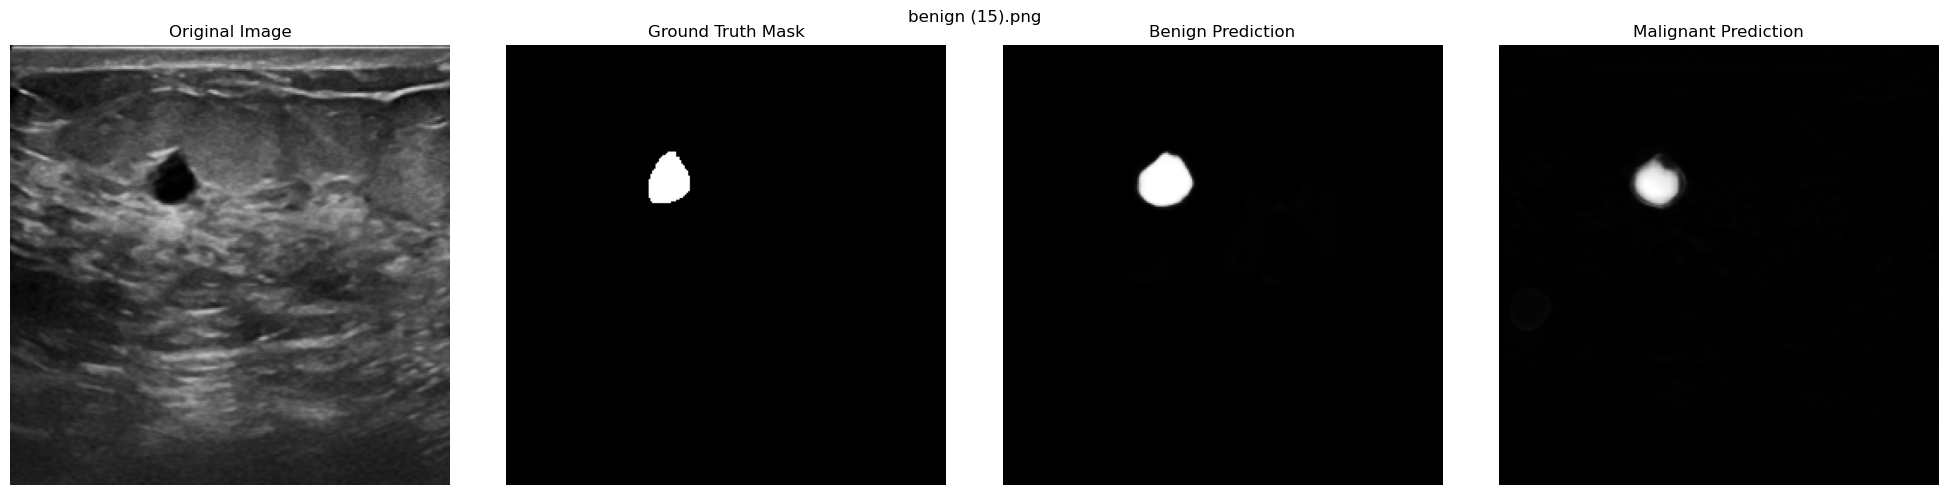

Inference completed!


In [104]:
if __name__ == "__main__":
    run_inference()